In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.metrics import mean_squared_error, accuracy_score
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, AdaBoostClassifier, AdaBoostRegressor
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt


In [2]:
df = pd.read_csv("D:\\New folder\\hoursPlayed_DTreg.csv")
df.head()

,Outlook,Temp,Humidity,Windy,Hours_Played
0,Rainy,Hot,High,False,25
1,Rainy,Hot,High,True,30
2,Overcast,Hot,High,False,46
3,Sunny,Mild,High,False,45
4,Sunny,Cool,Normal,False,52


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Outlook       14 non-null     object
 1   Temp          14 non-null     object
 2   Humidity      14 non-null     object
 3   Windy         14 non-null     bool  
 4   Hours_Played  14 non-null     int64 
dtypes: bool(1), int64(1), object(3)
memory usage: 594.0+ bytes


In [7]:
df.describe()

,Hours_Played
count,14.000000
mean,39.785714
std,9.672949
min,23.000000
25%,31.250000
50%,43.500000
75%,46.000000
max,52.000000


In [5]:
df.columns

Index(['Outlook', 'Temp', 'Humidity', 'Windy', 'Hours_Played'], dtype='object')

In [6]:
df["Hours_Played"]

0     25
1     30
2     46
3     45
4     52
5     23
6     43
7     35
8     38
9     48
10    46
11    52
12    44
13    30
Name: Hours_Played, dtype: int64

In [9]:
pd.crosstab(df['Temp'],df['Hours_Played'])

Hours_Played,23,25,30,35,38,43,44,45,46,48,52
Temp,,,,,,,,,,,
Cool,1,0,0,0,1,1,0,0,0,0,1
Hot,0,1,1,0,0,0,1,0,1,0,0
Mild,0,0,1,1,0,0,0,1,1,1,1


In [12]:
df_encoded = pd.get_dummies(df, columns=['Outlook', 'Temp', 'Humidity', 'Windy'], drop_first=True)
print("Dataset after Encoding:")
display(df_encoded)

Dataset after Encoding:


,Hours_Played,Outlook_Rainy,Outlook_Sunny,Temp_Hot,Temp_Mild,Humidity_Normal,Windy_True
0,25,True,False,True,False,False,False
1,30,True,False,True,False,False,True
2,46,False,False,True,False,False,False
3,45,False,True,False,True,False,False
4,52,False,True,False,False,True,False
5,23,False,True,False,False,True,True
6,43,False,False,False,False,True,True
7,35,True,False,False,True,False,False
8,38,True,False,False,False,True,False
9,48,False,True,False,True,True,False


In [14]:
X = df_encoded.drop('Hours_Played', axis=1)
y = df_encoded['Hours_Played']


In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [17]:
regressor = DecisionTreeRegressor(random_state=10)
regressor.fit(X_train, y_train)

DecisionTreeRegressor(random_state=10)

Original Dataset:


,Outlook,Temp,Humidity,Windy,Hours_Played
0,Rainy,Hot,High,False,25
1,Rainy,Hot,High,True,30
2,Overcast,Hot,High,False,46
3,Sunny,Mild,High,False,45
4,Sunny,Cool,Normal,False,52
5,Sunny,Cool,Normal,True,23
6,Overcast,Cool,Normal,True,43
7,Rainy,Mild,High,False,35
8,Rainy,Cool,Normal,False,38
9,Sunny,Mild,Normal,False,48


Dataset after Encoding:


,Hours_Played,Outlook_Rainy,Outlook_Sunny,Temp_Hot,Temp_Mild,Humidity_Normal,Windy_True
0,25,True,False,True,False,False,False
1,30,True,False,True,False,False,True
2,46,False,False,True,False,False,False
3,45,False,True,False,True,False,False
4,52,False,True,False,False,True,False
5,23,False,True,False,False,True,True
6,43,False,False,False,False,True,True
7,35,True,False,False,True,False,False
8,38,True,False,False,False,True,False
9,48,False,True,False,True,True,False


Model Evaluation:
Mean Squared Error (MSE): 63.333333333333336
R² Score: 0.5525902668759812


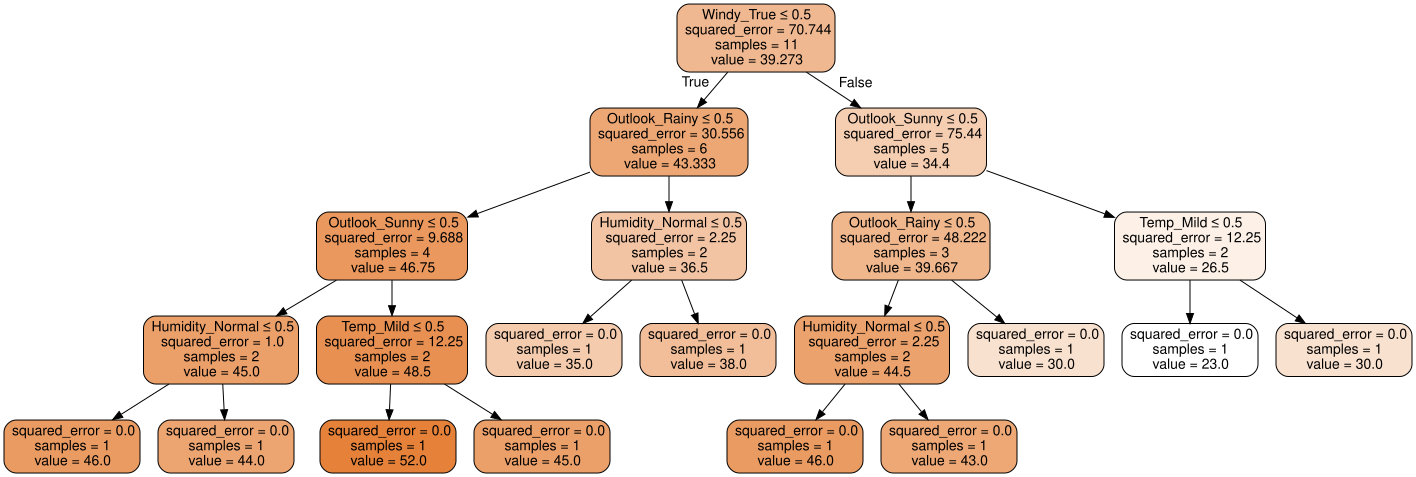

In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeRegressor, export_graphviz
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import graphviz

# -------------------------
# 1. Load the Dataset

df = pd.read_csv("D:\\New folder\\hoursPlayed_DTreg.csv")
print("Original Dataset:")
display(df)

# -------------------------
# 2. Preprocessing
# -------------------------
# The dataset contains categorical features (Outlook, Temp, Humidity, Windy).
# We convert them into numerical features using one-hot encoding.
df_encoded = pd.get_dummies(df, columns=['Outlook', 'Temp', 'Humidity', 'Windy'], drop_first=True)
print("Dataset after Encoding:")
display(df_encoded)

# -------------------------
# 3. Splitting Features and Target
# -------------------------
# The target variable is "Hours Played". All other columns are features.
X = df_encoded.drop('Hours_Played', axis=1)
y = df_encoded['Hours_Played']

# For evaluation purposes, we split the data into training and test sets.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# -------------------------
# 4. Building the Decision Tree Regressor
# -------------------------
# The DecisionTreeRegressor from scikit-learn uses variance reduction (similar in concept to standard deviation reduction)
# to choose the best splits.
regressor = DecisionTreeRegressor(random_state=42)
regressor.fit(X_train, y_train)

# -------------------------
# 5. Model Evaluation
# -------------------------
# Predict on the test set and compute evaluation metrics.
y_pred = regressor.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Model Evaluation:")
print("Mean Squared Error (MSE):", mse)
print("R² Score:", r2)

# -------------------------
# 6. Visualizing the Decision Tree
# -------------------------
# Export the decision tree into DOT format and display it.
dot_data = export_graphviz(
    regressor, 
    out_file=None, 
    feature_names=X.columns,
    filled=True, 
    rounded=True,
    special_characters=True
)

# Use graphviz to render the tree. If running in a Jupyter Notebook, the tree image should display inline.
graph = graphviz.Source(dot_data)
graph.render("decision_tree_regressor")  # This saves the tree to a file.
graph  # Display the tree in the notebook
